# PyTorch 基本组件和 Python class

前面的 notebook 已经训练了 logistic regression、MLP，并讨论了过拟合和正则化。本节不追求更高 accuracy，而是专门拆解一段 PyTorch 深度学习代码通常由哪些组件组成。

本节目标：

- 理解 Python `class` 的最基本写法。
- 理解为什么 PyTorch 模型通常写成 `class MyModel(nn.Module)`。
- 知道 `__init__` 里通常定义哪些层，`forward` 里通常写什么计算。
- 知道 `Dataset` 表示“一个一个样本”，`DataLoader` 表示“组成 mini-batch 并迭代”。
- 知道 optimizer 负责根据 gradients 更新 parameters。
- 能大概看懂一段标准训练代码：`zero_grad -> forward -> loss -> backward -> step`。

我们仍然使用 MNIST。每张图片可以看成 $x \in \mathbb{R}^{1 \times 28 \times 28}$，flatten 后是 $x \in \mathbb{R}^{784}$。模型输出 logits，形状是 `(batch_size, 10)`。

本节有些地方不会把底层实现完全展开。遇到不理解时，建议直接问 AI，但问题要尽量具体。目标不是深入拆解 PyTorch 源码，而是能说清楚：这个组件输入什么、输出什么、在训练流程中负责什么。

## 1. 准备环境

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 150

# Keep this introductory example CPU-only.
device = torch.device("cpu")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "dl_intro" else Path.cwd()
DATA_DIR = REPO_ROOT / "data"

## 2. Python class 最小例子

`class` 可以把数据和操作这些数据的函数放在一起。初学阶段先记住三个关键词：

- `class`: 定义一种新的对象类型。
- `__init__`: 创建对象时自动运行，通常用来保存属性。
- `self`: 代表“这个对象自己”。`self.value` 表示这个对象保存的 `value`。

下面这个例子和深度学习没有直接关系，只是为了看清楚 class 的基本语法。

**AI 使用指引。** 如果 Python `class` 的语法不熟，可以问 AI：`请用一个不涉及深度学习的例子解释 self、__init__、对象属性和方法之间的关系。` 重点是能看懂对象如何保存状态，以及方法如何读写这些状态。


In [2]:
class RunningMean:
    def __init__(self):
        self.total = 0.0
        self.count = 0

    def update(self, value):
        self.total += value
        self.count += 1

    def mean(self):
        return self.total / self.count


meter = RunningMean()
meter.update(2.0)
meter.update(4.0)
meter.update(6.0)

print(f"total = {meter.total}")
print(f"count = {meter.count}")
print(f"mean = {meter.mean()}")

total = 12.0
count = 3
mean = 4.0


上面代码中，`meter` 是一个对象。它内部保存了两个属性：`total` 和 `count`。每次调用 `meter.update(value)`，这两个属性都会改变。

PyTorch 模型也是对象。区别是：PyTorch 模型对象内部保存的是 layer 和 parameter。

## 3. PyTorch 模型为什么要继承 `nn.Module`

PyTorch 中，模型通常写成：

```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        ...

    def forward(self, x):
        ...
        return logits
```

`nn.Module` 是 PyTorch 提供的模型基类。继承它之后，PyTorch 能自动找到模型中的 parameters，例如 `nn.Linear` 的 weight 和 bias。这样 optimizer 才能通过 `model.parameters()` 拿到需要更新的参数。

**AI 使用指引。** 如果不理解 `nn.Module`、`__init__` 和 `forward` 的分工，可以问 AI：`为什么 PyTorch 模型通常继承 nn.Module？为什么 layer 写在 __init__，tensor 计算写在 forward？super().__init__() 大概负责什么？` 重点是理解模型对象如何保存 layers/parameters，以及 forward 如何定义计算路径。


In [3]:
class MNISTMLP(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        # __init__ defines layers and stores them as attributes.
        self.flatten = nn.Flatten()
        self.hidden = nn.Linear(28 * 28, hidden_size)
        self.activation = nn.ReLU()
        self.output = nn.Linear(hidden_size, 10)

    def forward(self, images):
        # forward describes how input tensors become output logits.
        X = self.flatten(images)          # (B, 1, 28, 28) -> (B, 784)
        hidden_logits = self.hidden(X)    # (B, 784) -> (B, hidden_size)
        hidden = self.activation(hidden_logits)
        logits = self.output(hidden)      # (B, hidden_size) -> (B, 10)
        return logits


model = MNISTMLP(hidden_size=64).to(device)
print(model)

MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden): Linear(in_features=784, out_features=64, bias=True)
  (activation): ReLU()
  (output): Linear(in_features=64, out_features=10, bias=True)
)


注意：平时我们写 `logits = model(images)`，而不是直接写 `model.forward(images)`。

`model(images)` 会在内部调用 `forward`，同时保留 PyTorch 需要的一些机制。初学阶段把 `forward` 理解成“这个模型的前向计算公式”即可。

## 4. 模型里面有哪些 parameters？

`nn.Linear(in_features, out_features)` 有两类可学习参数：

- `weight`: 形状是 `(out_features, in_features)`。
- `bias`: 形状是 `(out_features,)`。

模型的 parameters 是 optimizer 真正会更新的对象。

**AI 使用指引。** 如果 parameter、gradient、optimizer 的关系不清楚，可以问 AI：`nn.Linear(784,64) 的 weight 和 bias shape 为什么是这样？requires_grad=True、parameter.grad、optimizer.step() 三者如何关联？` 重点是能指出哪些 tensor 会被学习，以及它们在哪里被更新。


In [4]:
for name, parameter in model.named_parameters():
    print(f"{name:15s} shape = {tuple(parameter.shape)}, requires_grad = {parameter.requires_grad}")

hidden.weight   shape = (64, 784), requires_grad = True
hidden.bias     shape = (64,), requires_grad = True
output.weight   shape = (10, 64), requires_grad = True
output.bias     shape = (10,), requires_grad = True


## 5. Dataset：一个一个样本从哪里来

`Dataset` 表示一个可以按编号取样本的数据集。最重要的是两个方法：

- `__len__`: 数据集中有多少个样本。
- `__getitem__(index)`: 给定编号 `index`，返回一个样本。

下面先用一个很小的 toy dataset 看清楚接口。

**AI 使用指引。** 如果 `Dataset` 的接口不清楚，可以问 AI：`PyTorch Dataset 为什么需要 __len__ 和 __getitem__？dataset[0] 背后调用了什么？为什么一个监督学习样本通常返回 (x, y)？` 重点是理解 Dataset 负责“按编号取单个样本”。


In [5]:
class TinyDataset(Dataset):
    def __init__(self):
        self.features = torch.tensor([
            [0.0, 0.0],
            [0.0, 1.0],
            [1.0, 0.0],
            [1.0, 1.0],
        ])
        self.labels = torch.tensor([0, 1, 1, 0])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        x = self.features[index]
        y = self.labels[index]
        return x, y


tiny_dataset = TinyDataset()
print(f"len(tiny_dataset) = {len(tiny_dataset)}")
print(f"tiny_dataset[0] = {tiny_dataset[0]}")

len(tiny_dataset) = 4
tiny_dataset[0] = (tensor([0., 0.]), tensor(0))


MNIST dataset 也遵循同样接口。区别只是每个样本是一张图片和一个数字标签。

In [6]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

image, label = full_train_dataset[0]
print(f"number of training images = {len(full_train_dataset)}")
print(f"image.shape = {tuple(image.shape)}")
print(f"label = {label}")

number of training images = 60000
image.shape = (1, 28, 28)
label = 5


## 6. DataLoader：把样本组成 mini-batch

`DataLoader` 的工作是从 `Dataset` 里取出多个样本，组成一个 mini-batch。

如果 `batch_size = 32`，那么一个 batch 的 MNIST images 形状通常是 `(32, 1, 28, 28)`，labels 形状是 `(32,)`。

`shuffle=True` 表示每个 epoch 开始时打乱训练样本顺序。训练集通常需要 shuffle；test set 通常不需要。

**AI 使用指引。** 如果 `Dataset` 和 `DataLoader` 的边界不清楚，可以问 AI：`Dataset 返回单个样本，DataLoader 返回 mini-batch，这两者在训练循环中分别负责什么？batch_size 和 shuffle 会影响什么？` 重点是理解 DataLoader 负责把样本组织成可迭代的 batch。


In [7]:
FAST_DEV_RUN = True
BATCH_SIZE = 64

# Use a small subset so this notebook runs quickly on CPU.
train_indices = list(range(1024 if not FAST_DEV_RUN else 256))
test_indices = list(range(512 if not FAST_DEV_RUN else 128))

train_dataset = Subset(full_train_dataset, train_indices)
small_test_dataset = Subset(test_dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(small_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))

print(f"images.shape = {tuple(images.shape)}")
print(f"labels.shape = {tuple(labels.shape)}")
print(f"first 10 labels = {labels[:10].tolist()}")

images.shape = (64, 1, 28, 28)
labels.shape = (64,)
first 10 labels = [0, 0, 5, 4, 2, 1, 9, 7, 3, 7]


## 7. Loss：把 logits 和 labels 变成一个数字

模型输出的 `logits` 形状是 `(B, 10)`，其中 `B` 是 batch size。labels 形状是 `(B,)`，每个值是 0 到 9 的类别编号。

`nn.CrossEntropyLoss()` 会比较 logits 和真实 labels，输出一个标量 loss。注意：它需要 raw logits，不需要我们先做 softmax。

**AI 使用指引。** 如果 logits、labels、loss 的 shape 或含义容易混，可以问 AI：`在 MNIST batch 中，logits、labels、probabilities、CrossEntropyLoss 的输入输出 shape 分别是什么？为什么 CrossEntropyLoss 输入 raw logits？` 重点是避免把 softmax、loss 和 label 编码混在一起。


In [8]:
criterion = nn.CrossEntropyLoss()

images = images.to(device)
labels = labels.to(device)

logits = model(images)
loss = criterion(logits, labels)

print(f"logits.shape = {tuple(logits.shape)}")
print(f"loss = {loss.item():.4f}")

logits.shape = (64, 10)
loss = 2.2993


## 8. Optimizer：根据 gradients 更新 parameters

Optimizer 不会自己计算梯度。梯度来自 `loss.backward()`。

Optimizer 的工作是读取每个 parameter 的 `.grad`，然后更新 parameter。以 SGD 为例，可以粗略理解为：

$$\text{new parameter} = \text{old parameter} - \text{learning rate} \times \text{gradient}$$

下面只对一个 mini-batch 做一次训练 step，并观察 weight 是否发生变化。

**AI 使用指引。** 如果 `backward()` 和 `optimizer.step()` 的分工不清楚，可以问 AI：`loss.backward() 计算了什么？为什么 backward 前要 zero_grad？optimizer.step() 如何使用 parameter.grad 更新参数？` 重点是不要把“计算梯度”和“更新参数”混成同一步。


In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

before = model.hidden.weight.detach().clone()

optimizer.zero_grad()
logits = model(images)
loss = criterion(logits, labels)
loss.backward()

print(f"gradient shape = {tuple(model.hidden.weight.grad.shape)}")
print(f"gradient mean absolute value = {model.hidden.weight.grad.abs().mean().item():.6f}")

optimizer.step()

after = model.hidden.weight.detach().clone()
change = (after - before).abs().mean().item()
print(f"mean absolute parameter change = {change:.6f}")

gradient shape = (64, 784)
gradient mean absolute value = 0.001372
mean absolute parameter change = 0.000137


这段代码里，每一行都有固定职责：

```python
optimizer.zero_grad()       # 清空旧 gradients
logits = model(images)      # forward: 计算 logits
loss = criterion(logits, labels)
loss.backward()             # backward: 计算 gradients
optimizer.step()            # 用 gradients 更新 parameters
```

这是 PyTorch 训练代码最核心的结构。

## 9. 一个完整但很小的训练循环

下面把 model、Dataset、DataLoader、loss、optimizer 放在一起。为了课堂演示更快，这里只使用一小部分 MNIST。

**AI 使用指引。** 如果训练循环里的统计变量太多，可以问 AI：`epoch、batch、step、total_loss、total_correct、average loss 分别在统计什么？为什么 loss 要乘以 batch_size 再累加？` 重点是区分单个 batch 的 loss 和整个 epoch 的平均指标。


In [10]:
def accuracy_from_logits(logits, labels):
    predictions = logits.argmax(dim=1)
    return (predictions == labels).float().mean().item()


model = MNISTMLP(hidden_size=64).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

EPOCHS = 3 if not FAST_DEV_RUN else 1

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size

    average_loss = total_loss / total_examples
    train_accuracy = total_correct / total_examples
    print(f"epoch {epoch + 1}: loss = {average_loss:.4f}, train accuracy = {train_accuracy:.4f}")

epoch 1: loss = 2.2813, train accuracy = 0.1289


## 10. `model.train()`、`model.eval()` 和 `torch.no_grad()`

训练和评估时，代码通常会显式切换模式：

- `model.train()`: 训练模式。用于更新参数。
- `model.eval()`: 评估模式。用于 validation 或 test。
- `torch.no_grad()`: 告诉 PyTorch 不需要记录计算图，因此不计算 gradients。

对于本节这个简单 MLP，`train()` 和 `eval()` 的差别不明显。但如果模型里有 dropout 或 batch normalization，这两个模式就很重要。

**AI 使用指引。** 如果训练和评估边界不清楚，可以问 AI：`model.train()、model.eval()、torch.no_grad() 分别改变什么？为什么 validation/test 时通常不 backward，也不 optimizer.step()？` 重点是理解训练会更新参数，评估只测量表现。


In [11]:
model.eval()
total_correct = 0
total_examples = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += images.shape[0]

test_accuracy = total_correct / total_examples
print(f"small test accuracy = {test_accuracy:.4f}")

small test accuracy = 0.2031


## 11. 看一张图片的预测

现在我们用训练好的小模型看一张 MNIST 图片。这里的重点不是判断模型是否一定正确，而是看懂从 `Dataset` 到 `model` 到预测类别的流程。

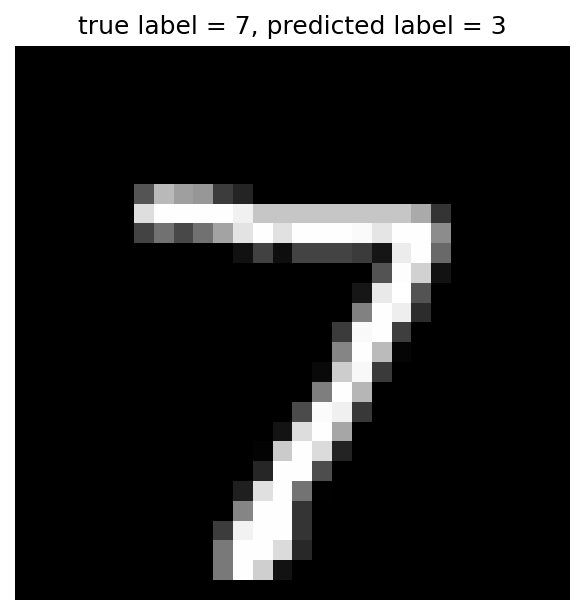

probabilities.shape = (1, 10)
predicted label = 3


In [12]:
image, label = small_test_dataset[0]

model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(device))
    probabilities = torch.softmax(logits, dim=1)
    predicted_label = logits.argmax(dim=1).item()

plt.imshow(image.squeeze(0), cmap="gray")
plt.axis("off")
plt.title(f"true label = {label}, predicted label = {predicted_label}")
plt.show()

print(f"probabilities.shape = {tuple(probabilities.shape)}")
print(f"predicted label = {predicted_label}")

## 12. 读 PyTorch 训练代码的顺序

以后看到一段新的 PyTorch 训练代码，可以按这个顺序读：

1. **Dataset**: 一个样本长什么样？`image.shape` 和 `label` 分别是什么？
2. **DataLoader**: 一个 batch 长什么样？`images.shape` 和 `labels.shape` 分别是什么？
3. **Model class**: `__init__` 里定义了哪些层？`forward` 里数据如何流动？
4. **Loss**: 模型输出和 labels 如何变成一个 loss？
5. **Optimizer**: 哪些 parameters 会被更新？learning rate 是多少？
6. **Training loop**: 是否按 `zero_grad -> forward -> loss -> backward -> step` 的顺序写？
7. **Evaluation**: 是否用了 `model.eval()` 和 `torch.no_grad()`？

先看懂这些主干，再去关心更复杂的技巧。

**AI 使用指引。** 如果读一段新训练代码时卡住，可以把相关代码发给 AI，并要求它按 `Dataset -> DataLoader -> Model -> Loss -> Optimizer -> Training loop -> Evaluation` 分类解释。重点是不必立刻从零写训练框架，但要能判断每段代码属于哪个组件、输入输出是什么。


## 13. 练习任务

这些任务不是为了追求最高 accuracy，而是为了确认你能读懂和修改基本 PyTorch 代码。

### 任务 1：修改模型结构

把 `MNISTMLP(hidden_size=64)` 改成 `hidden_size=32` 或 `hidden_size=128`。

记录：

- `model.named_parameters()` 中每个 parameter 的 shape 如何变化？
- `logits.shape` 是否仍然是 `(batch_size, 10)`？

### 任务 2：看懂 `forward`

在 `forward` 里临时加入 `print(X.shape)`、`print(hidden.shape)`、`print(logits.shape)`。

记录：

- 图片进入模型前是什么 shape？
- flatten 后是什么 shape？
- 最后 logits 是什么 shape？

完成后可以把这些 `print` 删除，避免训练时输出太多。

### 任务 3：修改 DataLoader

把 `BATCH_SIZE` 改成 `16`、`64`、`128`，观察第一个 batch 的 shape。

记录：

- `images.shape` 的第一个维度如何变化？
- `labels.shape` 如何变化？

### 任务 4：理解 optimizer

把 learning rate 从 `0.1` 改成 `0.01` 或 `0.5`。

记录：

- 第一个 epoch 的 loss 是否变化？
- `mean absolute parameter change` 是否变化？

### 任务 5：用 checklist 读第 04 个 notebook

回到 `04_mlp_mnist_pytorch.ipynb`，按第 12 节的顺序标出：

- Dataset 在哪里定义？
- DataLoader 在哪里定义？
- Model 在哪里定义？
- Loss 和 optimizer 在哪里定义？
- 哪几行对应 `zero_grad -> forward -> loss -> backward -> step`？

如果能完成这个任务，说明你已经能读懂 PyTorch 训练代码的基本骨架。